# Simulating an RGB-D camera



In [ ]:
# pip install numpy-stl pythreejs panel numpy pyvista open3d pydrake pydot ipyvtklink mpld3

In [1]:
# Let's do all of our imports here, too.
import os

import numpy as np
import matplotlib.animation as animation
import matplotlib.pyplot as plt, mpld3
import open3d
import pydot
from IPython.display import display, SVG, HTML

from pydrake.all import (
    AddMultibodyPlantSceneGraph, BaseField, CameraInfo, ClippingRange, CsdpSolver, DiagramBuilder, DepthImageToPointCloud, DepthRange, DepthRenderCamera, FindResourceOrThrow, ge, MakeRenderEngineVtk, MakePhongIllustrationProperties, MathematicalProgram, MeshcatPointCloudVisualizer, MeshcatVisualizerCpp, MeshcatVisualizerParams, Parser, RenderCameraCore, RenderEngineVtkParams, RgbdSensor, RigidTransform, RollPitchYaw, RotationMatrix)
from pydrake.examples.manipulation_station import ManipulationStation

from manipulation.meshcat_cpp_utils import StartMeshcat
from manipulation.scenarios import AddMultibodyTriad
from manipulation.utils import FindResource
from manipulation import running_as_notebook

import utils
from utils import FindResource

# if running_as_notebook:
#     mpld3.enable_notebook()
#     if os.getenv("DISPLAY") is None:
#       from pyvirtualdisplay import Display
#       virtual_display = Display(visible=0, size=(1400, 900))
#       virtual_display.start()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
meshcat = StartMeshcat()

Meshcat is now available at http://localhost:7000


# Simulating an RGB-D camera



In [3]:
def DepthCameraDemoSystem():
    builder = DiagramBuilder()

    # Create the physics engine + scene graph.
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    # Add a single object into it.
    X_Mustard = RigidTransform(RollPitchYaw(-np.pi/2., 0, -np.pi/2.), [0, 0, 0.09515])
    parser = Parser(plant)
    mustard = parser.AddModelFromFile(FindResourceOrThrow(
        "drake/manipulation/models/ycb/sdf/006_mustard_bottle.sdf"))
    plant.WeldFrames(plant.world_frame(), 
                     plant.GetFrameByName("base_link_mustard", mustard), 
                     X_Mustard)
    # Add a rendering engine
    renderer = "my_renderer"
    scene_graph.AddRenderer(renderer,
                            MakeRenderEngineVtk(RenderEngineVtkParams()))

    # Add a box for the camera in the environment.
    X_Camera = RigidTransform(
        RollPitchYaw(0, -0.2, 0.2).ToRotationMatrix().multiply(
            RollPitchYaw(-np.pi/2.0, 0, np.pi/2.0).ToRotationMatrix()),
        [.5, .1, .2])
    camera_instance = parser.AddModelFromFile(FindResource("models/camera_box.sdf"))
    camera = plant.GetBodyByName("base", camera_instance)    
    plant.WeldFrames(plant.world_frame(), camera.body_frame(), X_Camera)
    AddMultibodyTriad(camera.body_frame(), scene_graph, length=.1, radius=0.005)
    plant.Finalize()

    params = MeshcatVisualizerParams()
#    params.delete_on_initialization_event = False
    visualizer = MeshcatVisualizerCpp.AddToBuilder(
        builder, scene_graph, meshcat, params)

    depth_camera = DepthRenderCamera(RenderCameraCore(
        renderer, CameraInfo(width=640, height=480, fov_y=np.pi / 4.0),
        ClippingRange(near=0.1, far=10.0),
        RigidTransform()),
        DepthRange(0.1, 10.0))
    camera = builder.AddSystem(
        RgbdSensor(parent_id=plant.GetBodyFrameIdOrThrow(camera.index()),
                   X_PB=RigidTransform(),
                   depth_camera=depth_camera,
                   show_window=False))
    camera.set_name("rgbd_sensor")
    builder.Connect(scene_graph.get_query_output_port(),
                    camera.query_object_input_port())

    # Export the camera outputs
    builder.ExportOutput(camera.color_image_output_port(), "color_image")
    builder.ExportOutput(camera.depth_image_32F_output_port(), "depth_image")

    # Add a system to convert the camera output into a point cloud
    to_point_cloud = builder.AddSystem(
        DepthImageToPointCloud(camera_info=camera.depth_camera_info(),
                               fields=BaseField.kXYZs | BaseField.kRGBs))
    builder.Connect(camera.depth_image_32F_output_port(),
                    to_point_cloud.depth_image_input_port())
    builder.Connect(camera.color_image_output_port(),
                    to_point_cloud.color_image_input_port())

    # TODO(russt): Support point clouds in the new meshcat. (drake #15851)
    # Send the point cloud to meshcat for visualization, too.
#    meshcat_pointcloud = builder.AddSystem(MeshcatPointCloudVisualizer(meshcat, X_WP=X_Camera))
#    builder.Connect(to_point_cloud.point_cloud_output_port(), meshcat_pointcloud.get_input_port())

    # Export the point cloud output.
    builder.ExportOutput(to_point_cloud.point_cloud_output_port(),
                         "point_cloud")

    diagram = builder.Build()
    diagram.set_name("depth_camera_demo_system")
    return diagram


[2022-02-03 12:28:55.782] [console] [warning] Meshcat: Failed to load texture. "/usr/local/lib/python3.8/dist-packages/pydrake/share/drake/manipulation/models/ycb/meshes/006_mustard_bottle_textured.mtl" references 006_mustard_bottle_textured.png, but Meshcat could not open filename "/usr/local/lib/python3.8/dist-packages/pydrake/share/drake/manipulation/models/ycb/meshes/006_mustard_bottle_textured.png"


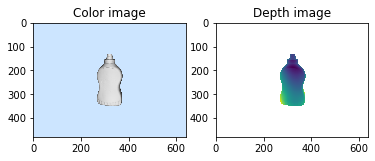

In [4]:
def plot_camera_images():
    system = DepthCameraDemoSystem()

    # Evaluate the camera output ports to get the images.
    context = system.CreateDefaultContext()
    system.Publish(context)
    color_image = system.GetOutputPort("color_image").Eval(context)
    depth_image = system.GetOutputPort("depth_image").Eval(context)

    # Plot the two images.
    plt.subplot(121)
    plt.imshow(color_image.data)
    plt.title('Color image')
    plt.subplot(122)
    plt.imshow(np.squeeze(depth_image.data))
    plt.title('Depth image')
    #mpld3.display()
    plt.show()

plot_camera_images()

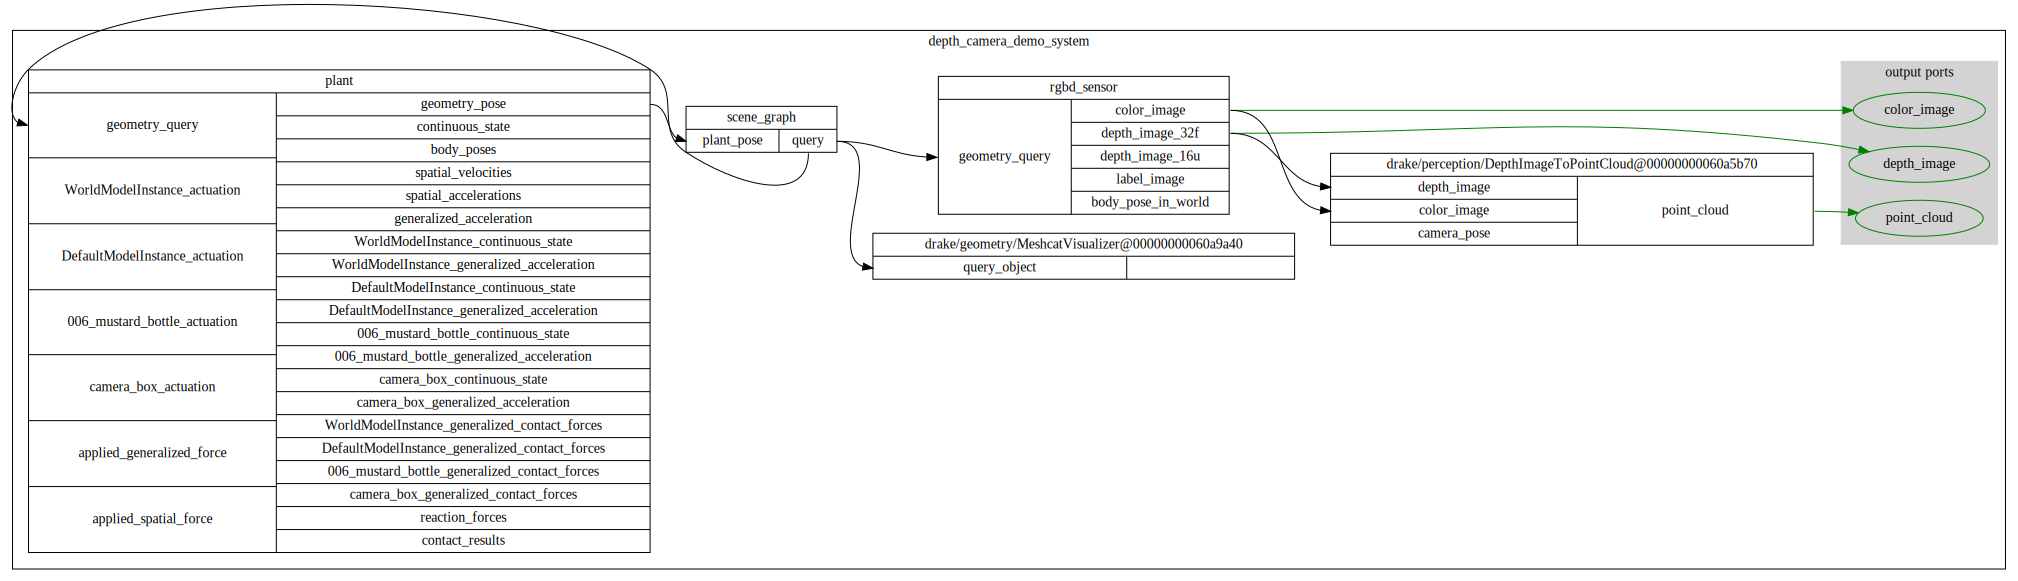

In [5]:
def draw_diagram():
    system = DepthCameraDemoSystem()
    display(SVG(pydot.graph_from_dot_data(system.GetGraphvizString(max_depth=1))[0].create_svg()))

draw_diagram()


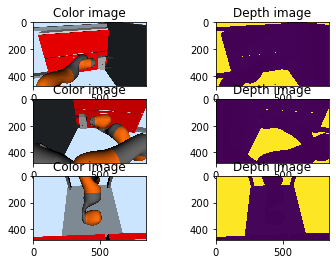

In [6]:
def plot_manipulation_station_camera_images():
    station = ManipulationStation()
    station.SetupManipulationClassStation()
    # station.SetupClutterClearingStation()
    station.Finalize()
    context = station.CreateDefaultContext()

    camera_names = station.get_camera_names()
    index = 1
    for name in camera_names:
        color_image = station.GetOutputPort("camera_" + name +
                                            "_rgb_image").Eval(context)
        depth_image = station.GetOutputPort("camera_" + name +
                                            "_depth_image").Eval(context)

        plt.subplot(len(camera_names), 2, index)
        plt.imshow(color_image.data)
        index += 1
        plt.title('Color image')
        plt.subplot(len(camera_names), 2, index)
        plt.imshow(np.squeeze(depth_image.data))
        index += 1
        plt.title('Depth image')

    plt.show()

plot_manipulation_station_camera_images()    

(3, 20)
(3, 20)
RigidTransform(
  R=RotationMatrix([
    [0.8950406032573506, -0.4459846617549958, 0.0],
    [0.4459846617549958, 0.8950406032573506, 0.0],
    [0.0, 0.0, 1.0],
  ]),
  p=[1.5372287914034968, 1.413471613754529, 0.0],
)
10
True position: [1.53722879 1.41347161 0.        ]
True orientation: AngleAxis_[float](angle=0.46227409051033436, axis=[0. 0. 1.])
Estimated position: [1.53722879 1.41347161 0.        ]
Estimated orientation: AngleAxis_[float](angle=0.4622740905103346, axis=[0. 0. 1.])


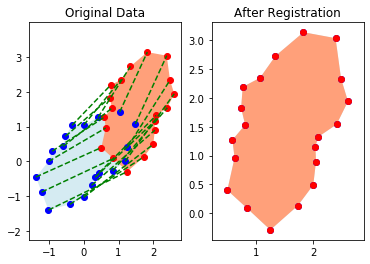

In [14]:
def MakeRandomObjectModelAndScenePoints(
    num_model_points=20, 
    noise_std=0, 
    num_outliers=0, 
    yaw_O=None,
    p_O=None, 
    num_viewable_points=None, 
    seed=None):
    """ Returns p_Om, p_s """
    random_state = np.random.RandomState(seed)

    # Make a random set of points to define our object in the x,y plane
    theta = np.arange(0, 2.0*np.pi, 2.0*np.pi/num_model_points)
    l = 1.0 + 0.5*np.sin(2.0*theta) + 0.4*random_state.rand(1, num_model_points)
    p_Om = np.vstack((l * np.sin(theta), l * np.cos(theta), 0 * l))

    # Make a random object pose if one is not specified, and apply it to get the scene points.
    if p_O is None:
        p_O = [2.0*random_state.rand(), 2.0*random_state.rand(), 0.0]
    if len(p_O) == 2:
        p_O.append(0.0)
    if yaw_O is None:
        yaw_O = 0.5*random_state.random()
    X_O = RigidTransform(RotationMatrix.MakeZRotation(yaw_O), p_O)
    if num_viewable_points is None:
        num_viewable_points = num_model_points
    assert num_viewable_points <= num_model_points
    p_s = X_O.multiply(p_Om[:,:num_viewable_points])
    p_s[:2, :]  += random_state.normal(scale=noise_std, size=(2, num_viewable_points))
    if num_outliers:
        outliers = random_state.uniform(low=-1.5, high=3.5, size=(3, num_outliers))
        outliers[2,:] = 0
        p_s = np.hstack((p_s, outliers))

    return p_Om, p_s, X_O

def MakeRectangleModelAndScenePoints(
    num_points_per_side=7,
    noise_std=0, 
    num_outliers=0, 
    yaw_O=None,
    p_O=None, 
    num_viewable_points=None, 
    seed=None):
    random_state = np.random.RandomState(seed)
    if p_O is None:
        p_O = [2.0*random_state.rand(), 2.0*random_state.rand(), 0.0]
    if len(p_O) == 2:
        p_O.append(0.0)
    if yaw_O is None:
        yaw_O = 0.5*random_state.random()
    X_O = RigidTransform(RotationMatrix.MakeZRotation(yaw_O), p_O)
    if num_viewable_points is None:
        num_viewable_points = 4*num_points_per_side
    
    x = np.arange(-1, 1, 2/num_points_per_side)
    half_width = 2
    half_height = 1
    top = np.vstack((half_width*x, half_height + 0*x))
    right = np.vstack((half_width + 0*x, -half_height*x))
    bottom = np.vstack((-half_width*x, -half_height + 0*x))
    left = np.vstack((-half_width + 0*x, half_height*x))
    p_Om = np.vstack((np.hstack((top, right, bottom, left)), np.zeros((1, 4*num_points_per_side))))
    p_s = X_O.multiply(p_Om[:,:num_viewable_points])
    p_s[:2, :]  += random_state.normal(scale=noise_std, size=(2, num_viewable_points))
    if num_outliers:
        outliers = random_state.uniform(low=-1.5, high=3.5, size=(3, num_outliers))
        outliers[2,:] = 0
        p_s = np.hstack((p_s, outliers))

    return p_Om, p_s, X_O


def PlotEstimate(p_Om, p_s, Xhat_O=RigidTransform(), chat=None, X_O=None, ax=None):
    p_m = Xhat_O.multiply(p_Om)
    if ax is None:
        ax = plt.subplot()
    Nm = p_Om.shape[1]
    artists = ax.plot(p_m[0, :], p_m[1, :], 'bo')
    artists += ax.fill(p_m[0, :], p_m[1, :], 'lightblue', alpha=0.5)
    artists += ax.plot(p_s[0, :], p_s[1, :], 'ro')
    if chat is not None:
        artists += ax.plot(np.vstack((p_m[0, chat], p_s[0, :])), np.vstack((p_m[1, chat], p_s[1, :])), 'g--')
    if X_O:
        p_s = X_O.multiply(p_Om)
    artists += ax.fill(p_s[0, :Nm], p_s[1, :Nm], 'lightsalmon')
    ax.axis('equal')
    return artists

def PrintResults(X_O, Xhat_O):
    p = X_O.translation()
    aa = X_O.rotation().ToAngleAxis()
    print(f"True position: {p}")
    print(f"True orientation: {aa}")
    p = Xhat_O.translation()
    aa = Xhat_O.rotation().ToAngleAxis()
    print(f"Estimated position: {p}")
    print(f"Estimated orientation: {aa}")

def PoseEstimationGivenCorrespondences(p_Om, p_s, chat):
    """ Returns optimal X_O given the correspondences """
    # Apply correspondences, and transpose data to support numpy broadcasting
    p_Omc = p_Om[:, chat].T
    p_s = p_s.T

    # Calculate the central points
    p_Ombar = p_Omc.mean(axis=0)
    p_sbar = p_s.mean(axis=0)

    # Calculate the "error" terms, and form the data matrix
    merr = p_Omc - p_Ombar
    serr = p_s - p_sbar
    W = np.matmul(serr.T, merr)

    # Compute R
    U, Sigma, Vt = np.linalg.svd(W)
    R = np.matmul(U, Vt)
    if np.linalg.det(R) < 0:
       print("fixing improper rotation")
       Vt[-1, :] *= -1
       R = np.matmul(U, Vt)

    # Compute p
    p = p_sbar - np.matmul(R, p_Ombar)

    return RigidTransform(RotationMatrix(R), p)


p_Om, p_s, X_O = MakeRandomObjectModelAndScenePoints(num_model_points=20)

print(p_Om.shape)
print(p_s.shape)
print(X_O)

#p_Om, p_s, X_O = MakeRectangleModelAndScenePoints()
Xhat = RigidTransform()
c = range(p_Om.shape[1])  # perfect, known correspondences
print(c[10])
fig, ax = plt.subplots(1, 2)
PlotEstimate(p_Om, p_s, Xhat, c, ax=ax[0])
Xhat = PoseEstimationGivenCorrespondences(p_Om, p_s, c)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_ylim(ax[0].get_ylim());
PlotEstimate(p_Om, p_s, Xhat, c, ax=ax[1])
ax[0].set_title('Original Data')
ax[1].set_title('After Registration')
PrintResults(X_O, Xhat)

# Iterative Closest Point (ICP)

In [8]:
def FindClosestPoints(point_cloud_A, point_cloud_B):
    """
    Finds the nearest (Euclidean) neighbor in point_cloud_B for each
    point in point_cloud_A.
    @param point_cloud_A A 3xN numpy array of points.
    @param point_cloud_B A 3xN numpy array of points.
    @return indices An (N, ) numpy array of the indices in point_cloud_B of each
        point_cloud_A point's nearest neighbor.
    """
    indices = np.empty(point_cloud_A.shape[1], dtype=int)

    # TODO(russt): Replace this with a direct call to flann
    # https://pypi.org/project/flann/
    kdtree = open3d.geometry.KDTreeFlann(point_cloud_B)
    for i in range(point_cloud_A.shape[1]):
        nn = kdtree.search_knn_vector_3d(point_cloud_A[:,i], 1)
        indices[i] = nn[1][0]

    return indices

def IterativeClosestPoint(p_Om, p_s, X_O=None, animate=True):
    Xhat = RigidTransform()
    Nm = p_s.shape[1]
    chat_previous = np.zeros(Nm)

    fig, ax = plt.subplots()
    frames = []
    frames.append(PlotEstimate(p_Om=p_Om, p_s=p_s, Xhat_O=Xhat, chat=None, X_O=X_O, ax=ax))

    while True:
        chat = FindClosestPoints(p_s, Xhat.multiply(p_Om))
        if np.array_equal(chat, chat_previous):
            # Then I've converged.
            break
        chat_previous = chat
        frames.append(PlotEstimate(p_Om=p_Om, p_s=p_s, Xhat_O=Xhat, chat=chat, X_O=X_O, ax=ax))
        Xhat = PoseEstimationGivenCorrespondences(p_Om, p_s, chat)
        frames.append(PlotEstimate(p_Om=p_Om, p_s=p_s, Xhat_O=Xhat, chat=None, X_O=X_O, ax=ax))

    ani = animation.ArtistAnimation(fig, frames, interval=400, repeat=False)

    display(HTML(ani.to_jshtml()))
    plt.close()

    if X_O:
        PrintResults(X_O, Xhat)

    return Xhat, chat
    

p_Om, p_s, X_O = MakeRandomObjectModelAndScenePoints(num_model_points=20)

print(p_Om.shape, " ", p_s.shape)
print(X_O)

IterativeClosestPoint(p_Om, p_s, X_O);

(3, 20)   (3, 20)
RigidTransform(
  R=RotationMatrix([
    [0.9999202524167596, -0.01262888778965398, 0.0],
    [0.01262888778965398, 0.9999202524167596, 0.0],
    [0.0, 0.0, 1.0],
  ]),
  p=[0.11290048166690458, 1.0132395392001274, 0.0],
)


INFO - 2022-02-03 12:29:02,149 - animation - Animation.save using <class 'matplotlib.animation.HTMLWriter'>


True position: [0.11290048 1.01323954 0.        ]
True orientation: AngleAxis_[float](angle=0.012629223508123177, axis=[0. 0. 1.])
Estimated position: [0.08806175 1.00095324 0.        ]
Estimated orientation: AngleAxis_[float](angle=0.033843490132840555, axis=[0. 0. 1.])


Try increasing the standard deviation on yaw in the example above.  At some point, the performance can get pretty poor!

# ICP with messy point clouds

Try changing the amount of noise, the number of outliers, and/or the partial views.  There are not particularly good theorems here, but I hope that a little bit of play will get you a lot of intuition.

In [8]:
#p_Om, p_s, X_O = MakeRandomObjectModelAndScenePoints(
p_Om, p_s, X_O = MakeRectangleModelAndScenePoints(
    yaw_O=0.1,
#    noise_std=0.2,
#    num_outliers=3,
    num_viewable_points=14)
IterativeClosestPoint(p_Om, p_s, X_O);

INFO - 2022-01-29 13:08:32,989 - animation - Animation.save using <class 'matplotlib.animation.HTMLWriter'>


True position: [1.90453449 0.03611323 0.        ]
True orientation: AngleAxis_[float](angle=0.09999999999999999, axis=[0. 0. 1.])
Estimated position: [ 1.66445438 -0.05779121  0.        ]
Estimated orientation: AngleAxis_[float](angle=0.1617769615603495, axis=[0. 0. 1.])


# Non-penetration constraints with nonlinear optimization

True position: [1.5 1.2 0. ]
True orientation: AngleAxis_[float](angle=0.2, axis=[0. 0. 1.])
Estimated position: [2.05079613 1.19999987 0.        ]
Estimated orientation: AngleAxis_[float](angle=0.05370553539207609, axis=[0. 0. 1.])


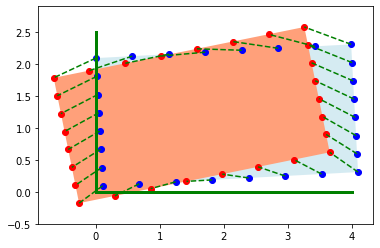

In [9]:
from pydrake.all import Solve
from functools import partial

def ConstrainedKnownCorrespondenceNonlinearOptimization(p_Om, p_s, chat):
    """ This version adds a non-penetration constraint (x,y >= 0) """

    p_Omc = p_Om[:2, chat]
    p_s = p_s[:2, :]
    Ns = p_s.shape[1]

    prog = MathematicalProgram()
    p = prog.NewContinuousVariables(2, 'p')
    theta = prog.NewContinuousVariables(1, 'theta')

    def position_model_in_world(vars, i):
        [p, theta] = np.split(vars, [2])
        R = np.array([[np.cos(theta[0]), -np.sin(theta[0])],
                      [np.sin(theta[0]), np.cos(theta[0])]])
        p_Wmci = p + R @ p_Omc[:,i]
        return p_Wmci

    def squared_distance(vars, i):
        p_Wmci = position_model_in_world(vars, i)
        err = p_Wmci - p_s[:,i]
        return err.dot(err)

    for i in range(Ns):
        prog.AddCost(partial(squared_distance, i=i),
                     np.concatenate([p[:], theta]))
        # forall i, p + R*mi >= 0.  
        prog.AddConstraint(partial(position_model_in_world, i=i), 
                           vars=np.concatenate([p[:], theta]),
                           lb=[0, 0], ub=[np.inf, np.inf])
    
    result = Solve(prog)
    
    theta_sol = result.GetSolution(theta[0])
    Rsol = np.array([[np.cos(theta_sol), -np.sin(theta_sol), 0],
                     [np.sin(theta_sol), np.cos(theta_sol), 0], 
                     [0, 0, 1]])
    psol = np.zeros(3)
    psol[:2] = result.GetSolution(p)

    return RigidTransform(RotationMatrix(Rsol), psol)

p_Om, p_s, X_O = MakeRectangleModelAndScenePoints(
    yaw_O=0.2,
    p_O = [1.5, 1.2],
)
c = range(p_Om.shape[1])  # perfect, known correspondences
Xhat_O = ConstrainedKnownCorrespondenceNonlinearOptimization(p_Om, p_s, c)
PlotEstimate(p_Om=p_Om, p_s=p_s, Xhat_O=Xhat_O, chat=c, X_O=X_O)
PrintResults(X_O, Xhat_O)
plt.gca().plot([0,0], [0, 2.5], 'g-', linewidth=3)
plt.gca().plot([0,4], [0, 0], 'g-', linewidth=3);

# Non-penetration (half-plane) constraints with convex optimization

[2022-01-29 13:08:57.376] [console] [warning] The problem has free variables, and CSDP removes the free variables by computing the null space of linear constraint in the dual space. This step can be time consuming. Consider providing a lower and/or upper bound for each decision variable.


True position: [1.5 1.2 0. ]
True orientation: AngleAxis_[float](angle=0.2, axis=[0. 0. 1.])
Estimated position: [1.80137219 1.23893751 0.        ]
Estimated orientation: AngleAxis_[float](angle=0.15576304752779327, axis=[0. 0. 1.])


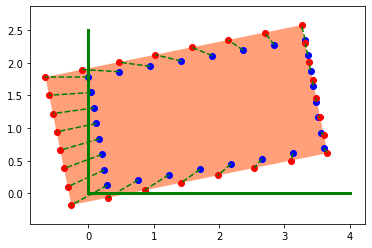

In [10]:
def ConstrainedKnownCorrespondenceConvexRelaxation(p_Om, p_s, chat):
    """ This version adds a non-penetration constraint (x,y >= 0) """

    p_Omc = p_Om[:2, chat]
    p_s = p_s[:2, :]
    Ns = p_s.shape[1]

    prog = MathematicalProgram()
    [a,b] = prog.NewContinuousVariables(2)
    # We use the slack variable as an upper bound on the cost of each point to make the objective linear.
    slack = prog.NewContinuousVariables(Ns)
    p = prog.NewContinuousVariables(2)
    prog.AddBoundingBoxConstraint(0,1,[a,b])  # This makes Csdp happier
    R = np.array([[a, -b],[b, a]])
    prog.AddLorentzConeConstraint([1.0, a, b])

    # Note: Could do this more efficiently, exploiting trace.  But I'm keeping it simpler here.
    prog.AddCost(np.sum(slack))
    for i in range(Ns):
        c = p + np.matmul(R,p_Omc[:,i]) - p_s[:,i]
        # forall i, slack[i]^2 >= |c|^2 
        prog.AddLorentzConeConstraint([slack[i], c[0], c[1]])
        # forall i, p + R*mi >= 0.  
        prog.AddConstraint(ge(p + np.matmul(R, p_Omc[:,i]), [0, 0]))
    
    result = CsdpSolver().Solve(prog)
    
    [a,b] = result.GetSolution([a,b])
    Rsol = np.array([[a, -b, 0],[b, a, 0], [0,0,1]])
    psol = np.zeros(3)
    psol[:2] = result.GetSolution(p)

    return RigidTransform(RotationMatrix(Rsol), psol)

p_Om, p_s, X_O = MakeRectangleModelAndScenePoints(
    yaw_O=0.2,
    p_O = [1.5, 1.2],
)
c = range(p_Om.shape[1])  # perfect, known correspondences
Xhat_O = ConstrainedKnownCorrespondenceConvexRelaxation(p_Om, p_s, c)
PlotEstimate(p_Om=p_Om, p_s=p_s, Xhat_O=Xhat_O, chat=c, X_O=X_O)
PrintResults(X_O, Xhat_O)
plt.gca().plot([0,0], [0, 2.5], 'g-', linewidth=3)
plt.gca().plot([0,4], [0, 0], 'g-', linewidth=3);